# Загрузка датасета и импорты

In [79]:
from IPython.display import display

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.metrics import roc_auc_score, make_scorer

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    StackingClassifier,
    VotingClassifier,
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier


In [80]:
test = pd.read_csv("test.csv")
train = pd.read_csv("train.csv")

# Переменные окружения и настройки

In [81]:
pd.set_option('display.max_columns', None)

plt.rcParams['figure.figsize'] = (10,5)

In [82]:
SEED=42

## EDA

## Знакомство с данными

In [83]:
train.shape

(595212, 59)

In [84]:
train.head()

,id,target,ps_ind_01,ps_ind_02_cat,ps_ind_03,ps_ind_04_cat,ps_ind_05_cat,ps_ind_06_bin,ps_ind_07_bin,ps_ind_08_bin,ps_ind_09_bin,ps_ind_10_bin,ps_ind_11_bin,ps_ind_12_bin,ps_ind_13_bin,ps_ind_14,ps_ind_15,ps_ind_16_bin,ps_ind_17_bin,ps_ind_18_bin,ps_reg_01,ps_reg_02,ps_reg_03,ps_car_01_cat,ps_car_02_cat,ps_car_03_cat,ps_car_04_cat,ps_car_05_cat,ps_car_06_cat,ps_car_07_cat,ps_car_08_cat,ps_car_09_cat,ps_car_10_cat,ps_car_11_cat,ps_car_11,ps_car_12,ps_car_13,ps_car_14,ps_car_15,ps_calc_01,ps_calc_02,ps_calc_03,ps_calc_04,ps_calc_05,ps_calc_06,ps_calc_07,ps_calc_08,ps_calc_09,ps_calc_10,ps_calc_11,ps_calc_12,ps_calc_13,ps_calc_14,ps_calc_15_bin,ps_calc_16_bin,ps_calc_17_bin,ps_calc_18_bin,ps_calc_19_bin,ps_calc_20_bin
0,7,0,2,2,5,1,0,0,1,0,0,0,0,0,0,0,11,0,1,0,0.7,0.2,0.718070,10,1,-1,0,1,4,1,0,0,1,12,2,0.400000,0.883679,0.370810,3.605551,0.6,0.5,0.2,3,1,10,1,10,1,5,9,1,5,8,0,1,1,0,0,1
1,9,0,1,1,7,0,0,0,0,1,0,0,0,0,0,0,3,0,0,1,0.8,0.4,0.766078,11,1,-1,0,-1,11,1,1,2,1,19,3,0.316228,0.618817,0.388716,2.449490,0.3,0.1,0.3,2,1,9,5,8,1,7,3,1,1,9,0,1,1,0,1,0
2,13,0,5,4,9,1,0,0,0,1,0,0,0,0,0,0,12,1,0,0,0.0,0.0,-1.000000,7,1,-1,0,-1,14,1,1,2,1,60,1,0.316228,0.641586,0.347275,3.316625,0.5,0.7,0.1,2,2,9,1,8,2,7,4,2,7,7,0,1,1,0,1,0
3,16,0,0,1,2,0,0,1,0,0,0,0,0,0,0,0,8,1,0,0,0.9,0.2,0.580948,7,1,0,0,1,11,1,1,3,1,104,1,0.374166,0.542949,0.294958,2.000000,0.6,0.9,0.1,2,4,7,1,8,4,2,2,2,4,9,0,0,0,0,0,0
4,17,0,0,2,0,1,0,1,0,0,0,0,0,0,0,0,9,1,0,0,0.7,0.6,0.840759,11,1,-1,0,-1,14,1,1,2,1,82,3,0.316070,0.565832,0.365103,2.000000,0.4,0.6,0.0,2,2,6,3,10,2,12,3,1,1,3,0,0,0,1,1,0


In [85]:
train.sample(10, random_state=SEED)

,id,target,ps_ind_01,ps_ind_02_cat,ps_ind_03,ps_ind_04_cat,ps_ind_05_cat,ps_ind_06_bin,ps_ind_07_bin,ps_ind_08_bin,ps_ind_09_bin,ps_ind_10_bin,ps_ind_11_bin,ps_ind_12_bin,ps_ind_13_bin,ps_ind_14,ps_ind_15,ps_ind_16_bin,ps_ind_17_bin,ps_ind_18_bin,ps_reg_01,ps_reg_02,ps_reg_03,ps_car_01_cat,ps_car_02_cat,ps_car_03_cat,ps_car_04_cat,ps_car_05_cat,ps_car_06_cat,ps_car_07_cat,ps_car_08_cat,ps_car_09_cat,ps_car_10_cat,ps_car_11_cat,ps_car_11,ps_car_12,ps_car_13,ps_car_14,ps_car_15,ps_calc_01,ps_calc_02,ps_calc_03,ps_calc_04,ps_calc_05,ps_calc_06,ps_calc_07,ps_calc_08,ps_calc_09,ps_calc_10,ps_calc_11,ps_calc_12,ps_calc_13,ps_calc_14,ps_calc_15_bin,ps_calc_16_bin,ps_calc_17_bin,ps_calc_18_bin,ps_calc_19_bin,ps_calc_20_bin
256886,642026,0,4,1,5,1,0,1,0,0,0,0,0,0,0,0,8,0,1,0,0.7,1.4,1.368393,10,1,-1,0,1,11,1,1,0,1,16,3,0.421782,0.596720,0.373497,1.414214,0.0,0.3,0.2,5,0,8,3,9,3,7,7,3,2,3,0,1,0,1,0,0
118785,297043,0,6,2,10,1,0,0,0,0,1,0,0,0,0,0,5,1,0,0,0.9,1.4,1.798437,10,0,-1,0,1,5,1,1,0,1,104,1,0.424264,1.237825,0.446094,3.162278,0.3,0.8,0.3,1,1,8,4,8,4,9,6,3,3,5,0,1,1,0,0,0
56083,140591,0,4,1,9,1,0,0,0,1,0,0,0,0,0,0,10,0,0,0,0.1,0.1,-1.000000,11,1,0,0,1,1,1,1,1,1,31,3,0.400000,0.546628,-1.000000,1.000000,0.2,0.6,0.3,5,1,8,2,8,2,12,3,1,0,7,0,0,1,0,0,0
542002,1354540,0,0,1,7,1,4,0,1,0,0,0,0,0,0,0,3,0,0,1,0.9,1.3,0.868907,11,1,1,0,1,15,1,0,2,1,97,3,0.360555,0.874147,0.298329,3.605551,0.4,0.8,0.1,3,2,7,4,10,2,5,1,1,3,6,1,1,0,0,0,0
349518,873173,0,1,1,3,1,0,1,0,0,0,0,0,0,0,0,12,0,1,0,0.6,0.4,0.741620,11,1,-1,0,-1,1,1,1,2,1,38,3,0.316228,0.740165,0.359861,3.464102,0.0,0.8,0.9,3,2,10,3,11,3,10,6,1,5,6,0,1,0,0,0,0
328884,821910,0,0,2,1,0,0,1,0,0,0,0,0,0,0,0,8,1,0,0,0.1,0.3,-1.000000,5,1,0,0,0,6,1,1,0,1,26,3,0.400000,0.630001,0.320468,2.645751,0.2,0.9,0.9,1,3,10,3,10,2,9,5,2,2,10,0,0,1,0,1,0
175820,439409,0,4,1,4,1,0,0,1,0,0,0,0,0,0,0,10,0,0,0,0.7,0.2,0.517204,7,1,0,0,0,0,1,1,2,1,22,3,0.316228,0.808980,0.310322,3.464102,0.7,0.0,0.5,5,1,6,3,10,7,10,3,2,9,9,0,0,1,0,0,0
30874,77431,0,0,1,4,0,0,1,0,0,0,0,0,0,0,0,4,1,0,0,0.2,0.2,-1.000000,11,1,0,1,1,16,1,1,2,1,104,2,0.400000,0.906143,0.388587,3.162278,0.5,0.6,0.2,2,3,9,1,11,3,6,10,1,3,6,0,1,1,0,0,0
367208,917681,0,4,2,2,0,0,0,0,0,1,0,0,0,0,0,2,0,0,1,0.8,1.2,1.327356,4,1,-1,0,0,1,1,1,0,1,70,3,0.374166,0.764231,0.393700,3.162278,0.9,0.1,0.8,3,2,9,6,11,1,9,5,2,4,6,0,0,1,0,1,0
276018,689844,0,1,1,3,0,3,1,0,0,0,0,0,0,0,0,8,1,0,0,0.9,0.3,0.814709,11,1,-1,0,-1,0,1,1,1,1,22,3,0.316228,0.784298,0.374566,3.464102,0.3,0.8,0.0,2,2,5,4,8,0,10,7,1,2,6,1,0,1,0,0,0


In [86]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 595212 entries, 0 to 595211
Data columns (total 59 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   id              595212 non-null  int64  
 1   target          595212 non-null  int64  
 2   ps_ind_01       595212 non-null  int64  
 3   ps_ind_02_cat   595212 non-null  int64  
 4   ps_ind_03       595212 non-null  int64  
 5   ps_ind_04_cat   595212 non-null  int64  
 6   ps_ind_05_cat   595212 non-null  int64  
 7   ps_ind_06_bin   595212 non-null  int64  
 8   ps_ind_07_bin   595212 non-null  int64  
 9   ps_ind_08_bin   595212 non-null  int64  
 10  ps_ind_09_bin   595212 non-null  int64  
 11  ps_ind_10_bin   595212 non-null  int64  
 12  ps_ind_11_bin   595212 non-null  int64  
 13  ps_ind_12_bin   595212 non-null  int64  
 14  ps_ind_13_bin   595212 non-null  int64  
 15  ps_ind_14       595212 non-null  int64  
 16  ps_ind_15       595212 non-null  int64  
 17  ps_ind_16_bin   59521

In [87]:
train.describe()

,id,target,ps_ind_01,ps_ind_02_cat,ps_ind_03,ps_ind_04_cat,ps_ind_05_cat,ps_ind_06_bin,ps_ind_07_bin,ps_ind_08_bin,ps_ind_09_bin,ps_ind_10_bin,ps_ind_11_bin,ps_ind_12_bin,ps_ind_13_bin,ps_ind_14,ps_ind_15,ps_ind_16_bin,ps_ind_17_bin,ps_ind_18_bin,ps_reg_01,ps_reg_02,ps_reg_03,ps_car_01_cat,ps_car_02_cat,ps_car_03_cat,ps_car_04_cat,ps_car_05_cat,ps_car_06_cat,ps_car_07_cat,ps_car_08_cat,ps_car_09_cat,ps_car_10_cat,ps_car_11_cat,ps_car_11,ps_car_12,ps_car_13,ps_car_14,ps_car_15,ps_calc_01,ps_calc_02,ps_calc_03,ps_calc_04,ps_calc_05,ps_calc_06,ps_calc_07,ps_calc_08,ps_calc_09,ps_calc_10,ps_calc_11,ps_calc_12,ps_calc_13,ps_calc_14,ps_calc_15_bin,ps_calc_16_bin,ps_calc_17_bin,ps_calc_18_bin,ps_calc_19_bin,ps_calc_20_bin
count,5.952120e+05,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000
mean,7.438036e+05,0.036448,1.900378,1.358943,4.423318,0.416794,0.405188,0.393742,0.257033,0.163921,0.185304,0.000373,0.001692,0.009439,0.000948,0.012451,7.299922,0.660823,0.121081,0.153446,0.610991,0.439184,0.551102,8.295933,0.829931,-0.504899,0.725192,-0.157732,6.555340,0.910027,0.832080,1.328890,0.992136,62.215674,2.346072,0.379945,0.813265,0.276256,3.065899,0.449756,0.449589,0.449849,2.372081,1.885886,7.689445,3.005823,9.225904,2.339034,8.433590,5.441382,1.441918,2.872288,7.539026,0.122427,0.627840,0.554182,0.287182,0.349024,0.153318
std,4.293678e+05,0.187401,1.983789,0.664594,2.699902,0.493311,1.350642,0.488579,0.436998,0.370205,0.388544,0.019309,0.041097,0.096693,0.030768,0.127545,3.546042,0.473430,0.326222,0.360417,0.287643,0.404264,0.793506,2.508270,0.375716,0.788654,2.153463,0.844417,5.501445,0.347106,0.373796,0.978747,0.091619,33.012455,0.832548,0.058327,0.224588,0.357154,0.731366,0.287198,0.286893,0.287153,1.117219,1.134927,1.334312,1.414564,1.459672,1.246949,2.904597,2.332871,1.202963,1.694887,2.746652,0.327779,0.483381,0.497056,0.452447,0.476662,0.360295
min,7.000000e+00,0.000000,0.000000,-1.000000,0.000000,-1.000000,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-1.000000,-1.000000,-1.000000,-1.000000,0.000000,-1.000000,0.000000,-1.000000,0.000000,-1.000000,0.000000,1.000000,-1.000000,-1.000000,0.250619,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.719915e+05,0.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,0.000000,0.000000,0.000000,0.400000,0.200000,0.525000,7.000000,1.000000,-1.000000,0.000000,-1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,32.000000,2.000000,0.316228,0.670867,0.333167,2.828427,0.200000,0.200000,0.200000,2.000000,1.000000,7.000000,2.000000,8.000000,1.000000,6.000000,4.000000,1.000000,2.000000,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,7.435475e+05,0.000000,1.000000,1.000000,4.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.000000,1.000000,0.000000,0.000000,0.700000,0.300000,0.720677,7.000000,1.000000,-1.000000,0.000000,0.000000,7.0000

Замечаем по таргету, что есть явный дисбаланс классов по `target`.

In [88]:
train.isnull().sum()

id                0
target            0
ps_ind_01         0
ps_ind_02_cat     0
ps_ind_03         0
ps_ind_04_cat     0
ps_ind_05_cat     0
ps_ind_06_bin     0
ps_ind_07_bin     0
ps_ind_08_bin     0
ps_ind_09_bin     0
ps_ind_10_bin     0
ps_ind_11_bin     0
ps_ind_12_bin     0
ps_ind_13_bin     0
ps_ind_14         0
ps_ind_15         0
ps_ind_16_bin     0
ps_ind_17_bin     0
ps_ind_18_bin     0
ps_reg_01         0
ps_reg_02         0
ps_reg_03         0
ps_car_01_cat     0
ps_car_02_cat     0
ps_car_03_cat     0
ps_car_04_cat     0
ps_car_05_cat     0
ps_car_06_cat     0
ps_car_07_cat     0
ps_car_08_cat     0
ps_car_09_cat     0
ps_car_10_cat     0
ps_car_11_cat     0
ps_car_11         0
ps_car_12         0
ps_car_13         0
ps_car_14         0
ps_car_15         0
ps_calc_01        0
ps_calc_02        0
ps_calc_03        0
ps_calc_04        0
ps_calc_05        0
ps_calc_06        0
ps_calc_07        0
ps_calc_08        0
ps_calc_09        0
ps_calc_10        0
ps_calc_11        0


In [89]:
test.isnull().sum()

id                0
ps_ind_01         0
ps_ind_02_cat     0
ps_ind_03         0
ps_ind_04_cat     0
ps_ind_05_cat     0
ps_ind_06_bin     0
ps_ind_07_bin     0
ps_ind_08_bin     0
ps_ind_09_bin     0
ps_ind_10_bin     0
ps_ind_11_bin     0
ps_ind_12_bin     0
ps_ind_13_bin     0
ps_ind_14         0
ps_ind_15         0
ps_ind_16_bin     0
ps_ind_17_bin     0
ps_ind_18_bin     0
ps_reg_01         0
ps_reg_02         0
ps_reg_03         0
ps_car_01_cat     0
ps_car_02_cat     0
ps_car_03_cat     0
ps_car_04_cat     0
ps_car_05_cat     0
ps_car_06_cat     0
ps_car_07_cat     0
ps_car_08_cat     0
ps_car_09_cat     0
ps_car_10_cat     0
ps_car_11_cat     0
ps_car_11         0
ps_car_12         0
ps_car_13         0
ps_car_14         0
ps_car_15         0
ps_calc_01        0
ps_calc_02        0
ps_calc_03        0
ps_calc_04        0
ps_calc_05        0
ps_calc_06        0
ps_calc_07        0
ps_calc_08        0
ps_calc_09        0
ps_calc_10        0
ps_calc_11        0
ps_calc_12        0


Пропусков совсем нет.
Было бы приятно, но после этого наблюдения нашёл в описании, что пропуски заполнены `-1`.

In [90]:
(train == -1).sum()

id                     0
target                 0
ps_ind_01              0
ps_ind_02_cat        216
ps_ind_03              0
ps_ind_04_cat         83
ps_ind_05_cat       5809
ps_ind_06_bin          0
ps_ind_07_bin          0
ps_ind_08_bin          0
ps_ind_09_bin          0
ps_ind_10_bin          0
ps_ind_11_bin          0
ps_ind_12_bin          0
ps_ind_13_bin          0
ps_ind_14              0
ps_ind_15              0
ps_ind_16_bin          0
ps_ind_17_bin          0
ps_ind_18_bin          0
ps_reg_01              0
ps_reg_02              0
ps_reg_03         107772
ps_car_01_cat        107
ps_car_02_cat          5
ps_car_03_cat     411231
ps_car_04_cat          0
ps_car_05_cat     266551
ps_car_06_cat          0
ps_car_07_cat      11489
ps_car_08_cat          0
ps_car_09_cat        569
ps_car_10_cat          0
ps_car_11_cat          0
ps_car_11              5
ps_car_12              1
ps_car_13              0
ps_car_14          42620
ps_car_15              0
ps_calc_01             0


In [91]:
(test == -1).sum()

id                     0
ps_ind_01              0
ps_ind_02_cat        307
ps_ind_03              0
ps_ind_04_cat        145
ps_ind_05_cat       8710
ps_ind_06_bin          0
ps_ind_07_bin          0
ps_ind_08_bin          0
ps_ind_09_bin          0
ps_ind_10_bin          0
ps_ind_11_bin          0
ps_ind_12_bin          0
ps_ind_13_bin          0
ps_ind_14              0
ps_ind_15              0
ps_ind_16_bin          0
ps_ind_17_bin          0
ps_ind_18_bin          0
ps_reg_01              0
ps_reg_02              0
ps_reg_03         161684
ps_car_01_cat        160
ps_car_02_cat          5
ps_car_03_cat     616911
ps_car_04_cat          0
ps_car_05_cat     400359
ps_car_06_cat          0
ps_car_07_cat      17331
ps_car_08_cat          0
ps_car_09_cat        877
ps_car_10_cat          0
ps_car_11_cat          0
ps_car_11              1
ps_car_12              0
ps_car_13              0
ps_car_14          63805
ps_car_15              0
ps_calc_01             0
ps_calc_02             0


Всё-таки есть. Неприятно.

In [92]:
for column in train.columns:
    print(f"{column}:{train[column].unique().size}")

id:595212
target:2
ps_ind_01:8
ps_ind_02_cat:5
ps_ind_03:12
ps_ind_04_cat:3
ps_ind_05_cat:8
ps_ind_06_bin:2
ps_ind_07_bin:2
ps_ind_08_bin:2
ps_ind_09_bin:2
ps_ind_10_bin:2
ps_ind_11_bin:2
ps_ind_12_bin:2
ps_ind_13_bin:2
ps_ind_14:5
ps_ind_15:14
ps_ind_16_bin:2
ps_ind_17_bin:2
ps_ind_18_bin:2
ps_reg_01:10
ps_reg_02:19
ps_reg_03:5013
ps_car_01_cat:13
ps_car_02_cat:3
ps_car_03_cat:3
ps_car_04_cat:10
ps_car_05_cat:3
ps_car_06_cat:18
ps_car_07_cat:3
ps_car_08_cat:2
ps_car_09_cat:6
ps_car_10_cat:3
ps_car_11_cat:104
ps_car_11:5
ps_car_12:184
ps_car_13:70482
ps_car_14:850
ps_car_15:15
ps_calc_01:10
ps_calc_02:10
ps_calc_03:10
ps_calc_04:6
ps_calc_05:7
ps_calc_06:11
ps_calc_07:10
ps_calc_08:11
ps_calc_09:8
ps_calc_10:26
ps_calc_11:20
ps_calc_12:11
ps_calc_13:14
ps_calc_14:24
ps_calc_15_bin:2
ps_calc_16_bin:2
ps_calc_17_bin:2
ps_calc_18_bin:2
ps_calc_19_bin:2
ps_calc_20_bin:2


В названии столбцов содержится смысл данных:
* ps_ind_ - индивидуальные характеристики человека
* ps_car_ - характеристика автомобиля
* ps_reg_ - региональные характеристики
* ps_calc_ - рассчитанные признаки

А так же тип признака в суффиксе:
* \_bin - бинарный признак
* \_cat - категориальный
* без суффикса - числовой непрерывный или порядковый

## Анализ целевой переменной

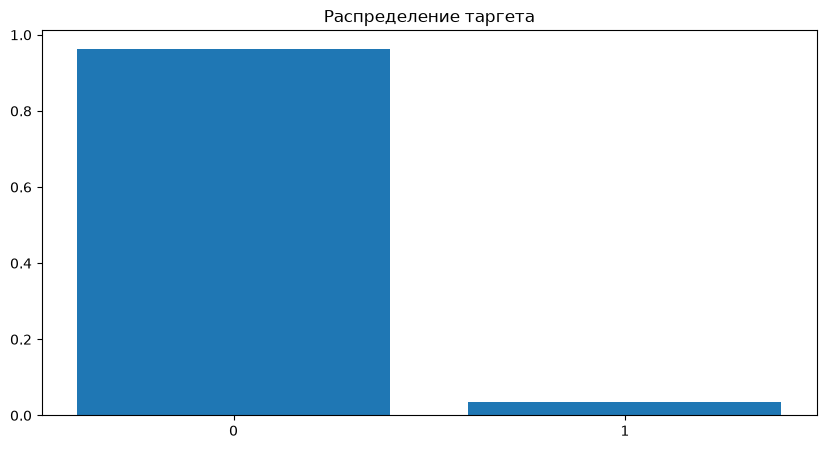

In [93]:
target_counts = train["target"].value_counts(normalize=True)
fig_1, ax_1 = plt.subplots()

ax_1.bar(target_counts.index, target_counts)
ax_1.set_title("Распределение таргета")
ax_1.set_xticks(target_counts.index)
ax_1.set_xticklabels(target_counts.index)

plt.show()

Утверждаем предположение о сильном дисбалансе. Необходимо использовать стратификацию.


В качестве метрики соревнования указан Normalized Gini Coefficient. Он уместен при дисбалансе.

## Анализ пропусков

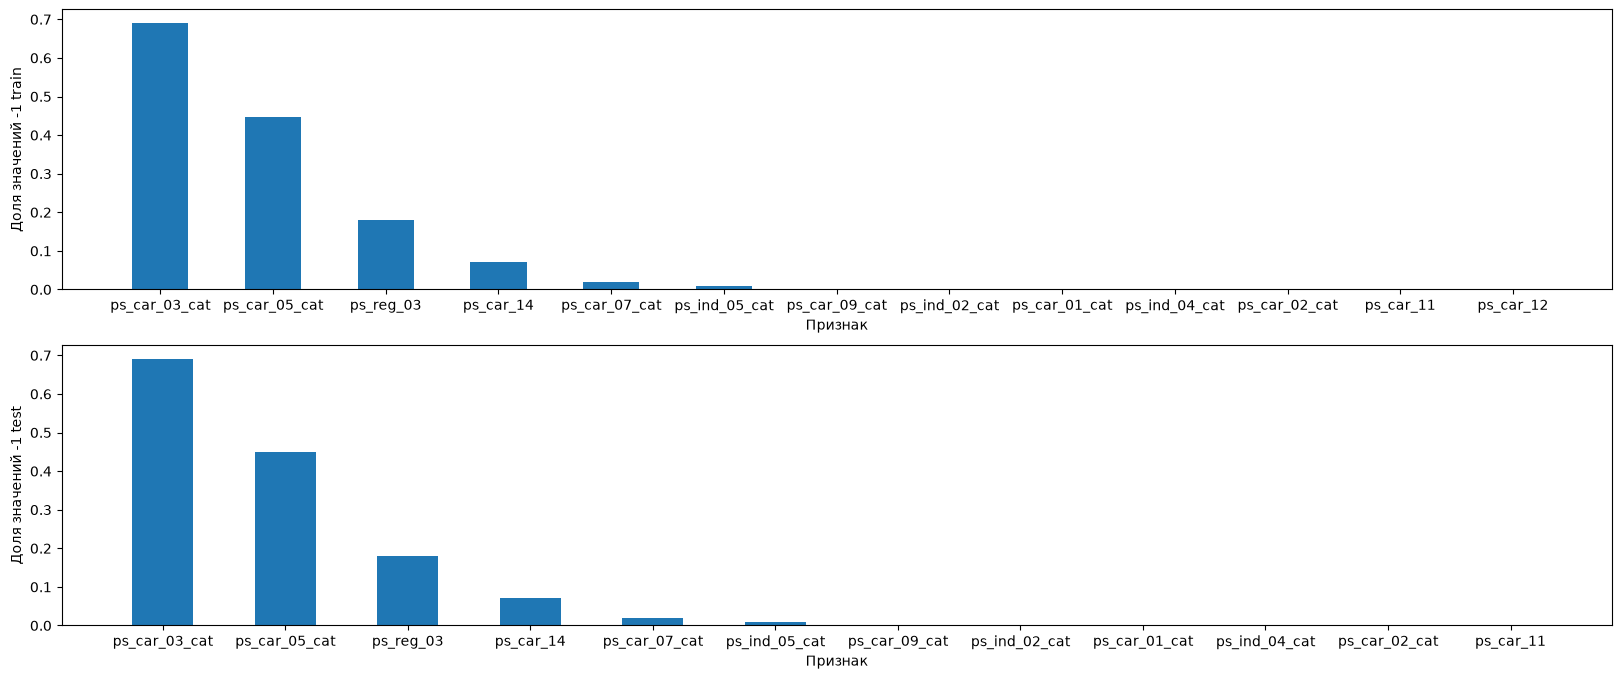

In [94]:
missings_train = (train == -1).mean()
top_missings_train = missings_train[missings_train > 0].sort_values(ascending=False)

missings_test = (test == -1).mean()
top_missings_test = missings_test[missings_test > 0].sort_values(ascending=False)

fig_2,ax_2 = plt.subplots(2,1,figsize=(20,8))
ax_2[0].bar(top_missings_train.index, top_missings_train, width=0.5)
ax_2[1].bar(top_missings_test.index, top_missings_test, width=0.5)

ax_2[0].set_ylabel("Доля значений -1 train")
ax_2[0].set_xlabel("Признак")

ax_2[1].set_ylabel("Доля значений -1 test")
ax_2[1].set_xlabel("Признак")
plt.show()

In [95]:
missings = pd.DataFrame({
    'train': top_missings_train,
    'test': top_missings_test,
})

missings = missings.sort_values(by='train', ascending=False)

display(missings)

,train,test
ps_car_03_cat,0.690898,0.690972
ps_car_05_cat,0.447825,0.448423
ps_reg_03,0.181065,0.181094
ps_car_14,0.071605,0.071465
ps_car_07_cat,0.019302,0.019412
ps_ind_05_cat,0.009760,0.009756
ps_car_09_cat,0.000956,0.000982
ps_ind_02_cat,0.000363,0.000344
ps_car_01_cat,0.000180,0.000179
ps_ind_04_cat,0.000139,0.000162


Доли пропущенных значений в train и test почти одинаковые.

## Анализ признаков

### Heat map по бинарным и числовым признакам

In [96]:
bin_features = [c for c in train.columns if c.endswith('_bin')]
cat_features = [c for c in train.columns if c.endswith('_cat')]
num_features = [c for c in train.columns if not(c.endswith('_bin')) and not(c.endswith('_cat')) and c not in ['id', 'target']]

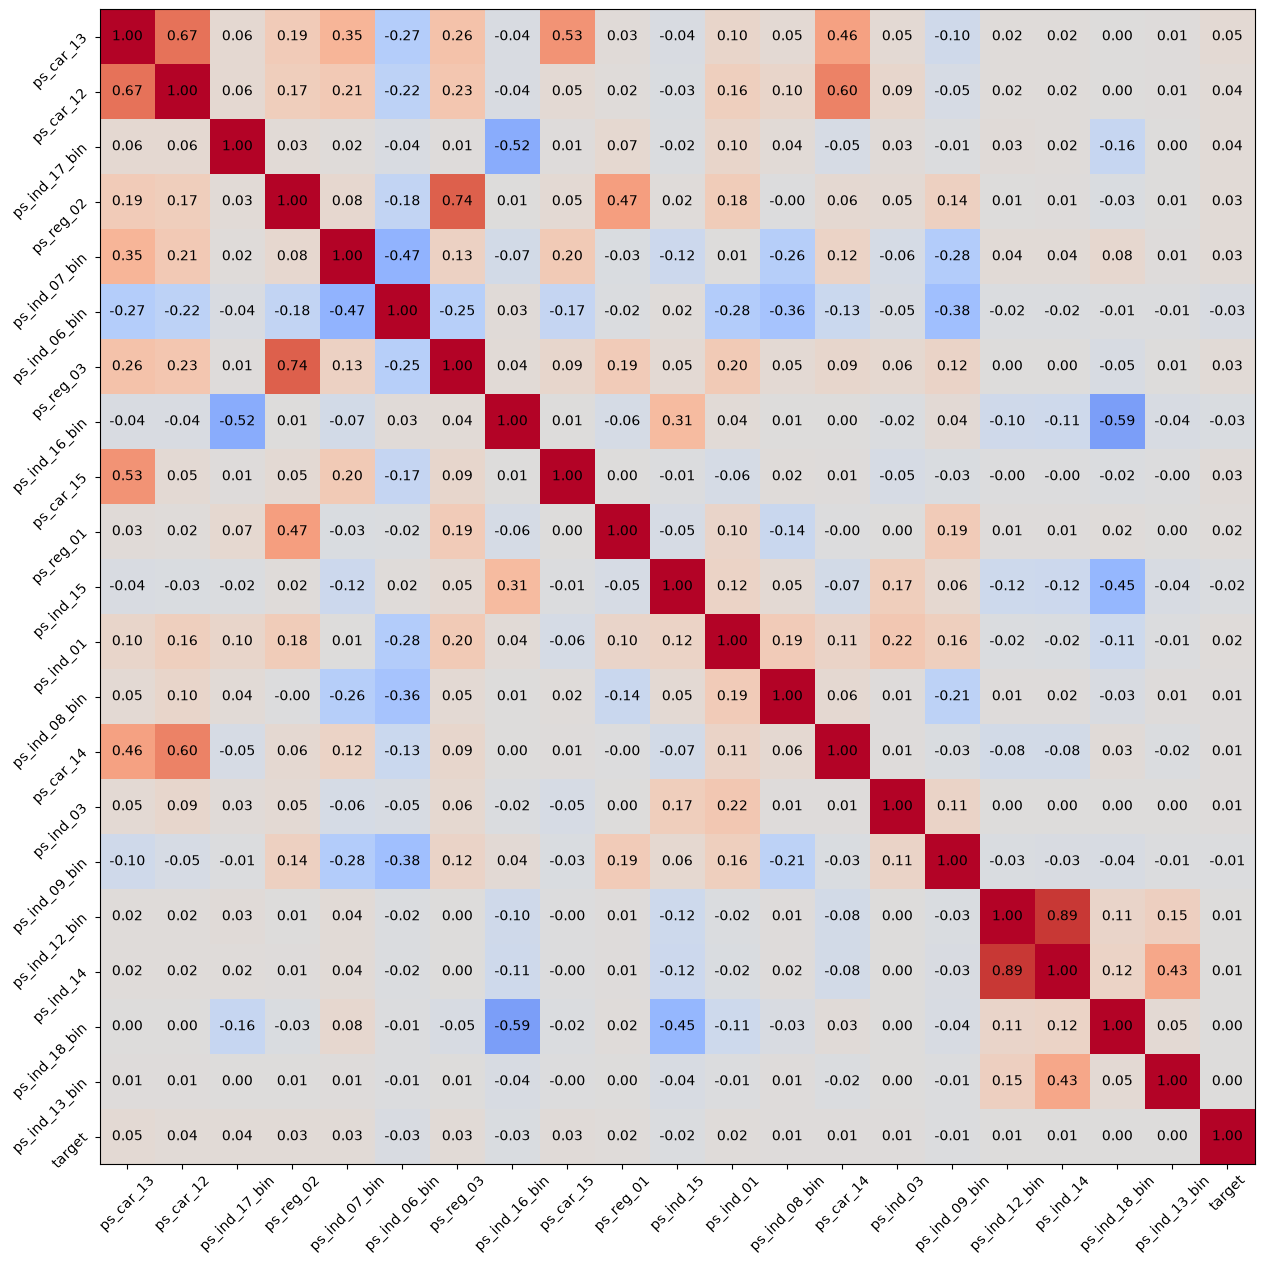

In [97]:
train["target"] = train.pop("target")
corr_features = num_features + bin_features + ['target']
corr_matrix = train[corr_features].replace(-1, np.nan).corr()

top_features = (
    corr_matrix['target']
    .drop('target')
    .abs()
    .nlargest(20)
    .index
    .tolist()
)
selected_features = top_features + ['target']

corr_matrix = corr_matrix.loc[selected_features, selected_features]

fig_3, ax_3 = plt.subplots(figsize=(15,15))

image = ax_3.imshow(
    corr_matrix,
    vmin=-1,
    vmax=1,
    cmap = 'coolwarm',
)

for i in range(corr_matrix.shape[0]):
    for j in range(corr_matrix.shape[1]):
        ax_3.text(j, i,
                  f'{corr_matrix.iloc[i,j]:.2f}', ha='center', va='center')

ax_3.set_xticks(np.arange(len(selected_features)))
ax_3.set_yticks(np.arange(len(selected_features)))
ax_3.set_xticklabels(selected_features, rotation=45)
ax_3.set_yticklabels(selected_features, rotation=45)

plt.show()

### Категориальные признаки

In [98]:
for column in cat_features:
    print(f'{column}:{train[column].unique().size}')

ps_ind_02_cat:5
ps_ind_04_cat:3
ps_ind_05_cat:8
ps_car_01_cat:13
ps_car_02_cat:3
ps_car_03_cat:3
ps_car_04_cat:10
ps_car_05_cat:3
ps_car_06_cat:18
ps_car_07_cat:3
ps_car_08_cat:2
ps_car_09_cat:6
ps_car_10_cat:3
ps_car_11_cat:104


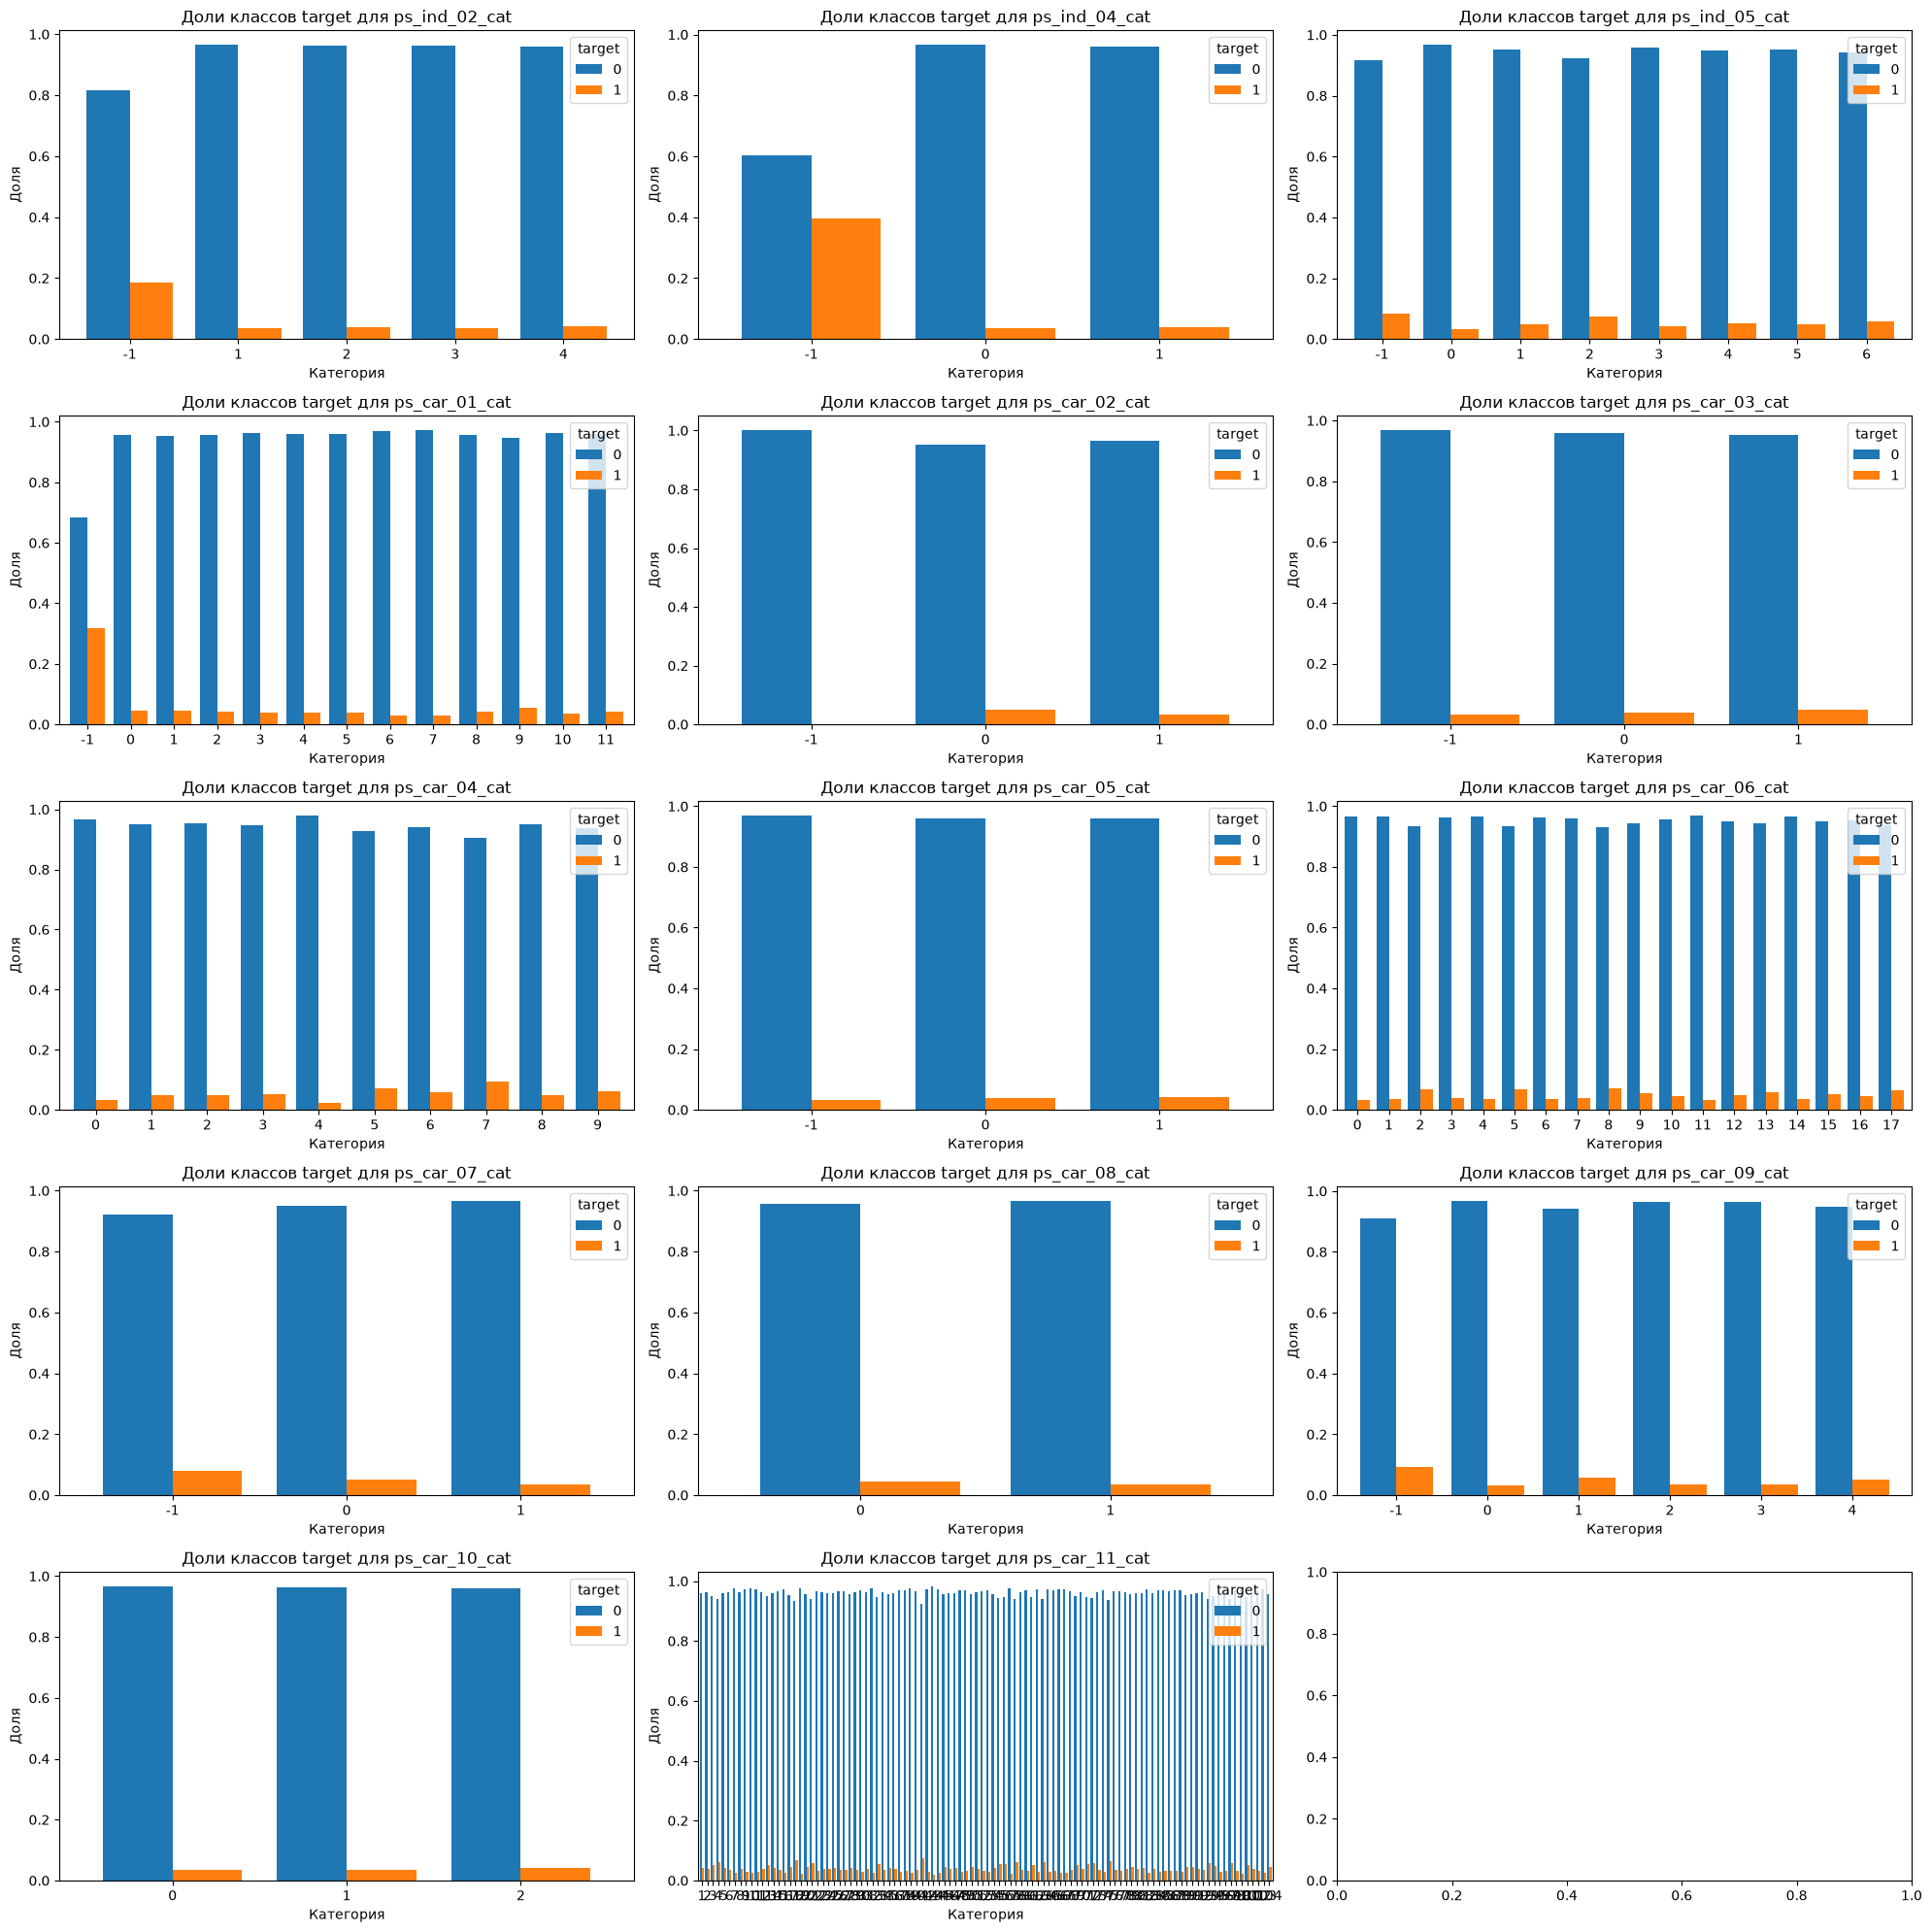

In [99]:
cat_feat_shares_by_target = {}
fig_4, ax_4 = plt.subplots(5,3,figsize=(20,20))

for i in range(len(cat_features)):
    shares = pd.crosstab(
        train[cat_features[i]],
        train["target"],
        normalize="index"
    )

    row = i // 3
    col = i % 3

    shares.plot.bar(
        ax=ax_4[row,col],
        width=0.8,
    )

    ax_4[row, col].set_title(f"Доли классов target для {cat_features[i]}")
    ax_4[row, col].set_xlabel("Категория")
    ax_4[row, col].set_ylabel("Доля")
    ax_4[row, col].legend(title="target")
    ax_4[row, col].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

Доля положительного класса высокие значения наблюдаются для категории `-1`, обозначающей пропуск. Однако для `ps_ind_02_cat`, `ps_ind_04_cat` и `ps_car_01_cat` количество пропущенных значений невелико, поэтому высокая доля положительного класса может быть нестабильной. Более надёжными выглядят различия для `ps_ind_05_cat` и `ps_car_07_cat`, где категория `-1` представлена большим количеством объектов.

Из этого можно сделать вывод, что пропуски для ряда признаков следует оставить отдельной категорией.

## Бинарные признаки

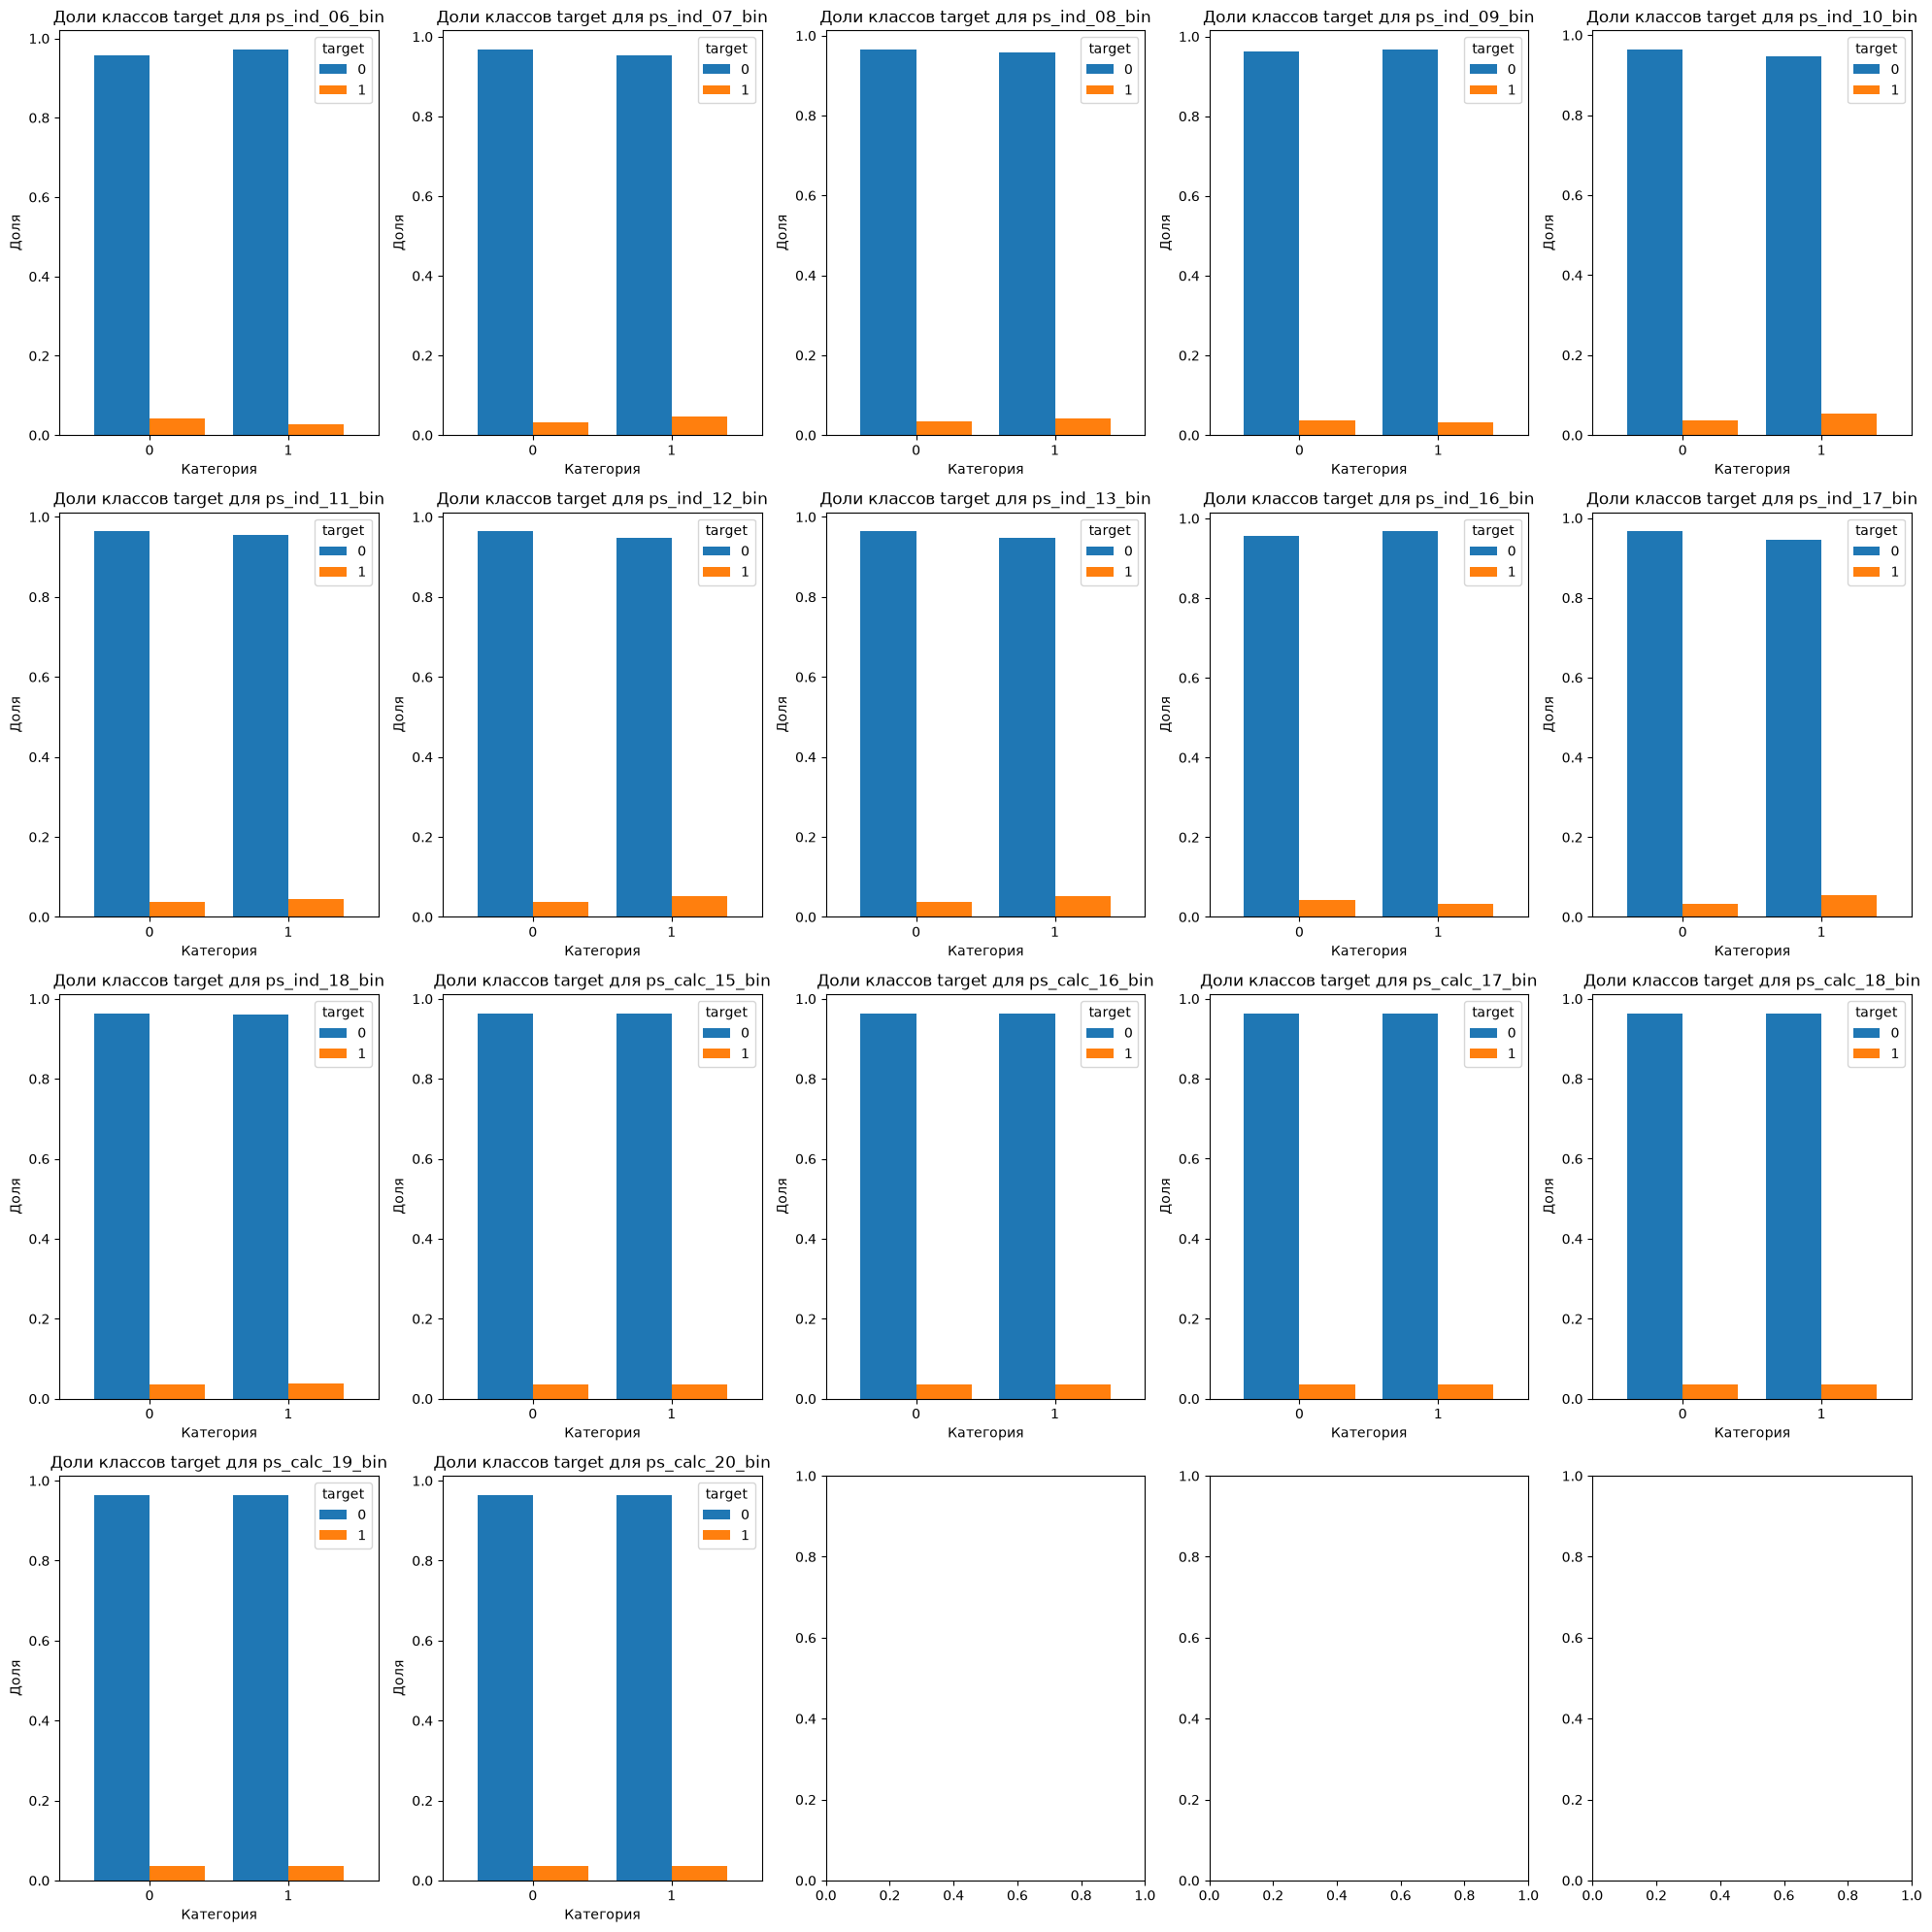

In [100]:
bin_feat_shares_by_target = {}
fig_5, ax_5 = plt.subplots(4,5,figsize=(20,20))

for i in range(len(bin_features)):
    shares = pd.crosstab(
        train[bin_features[i]],
        train["target"],
        normalize="index"
    )

    row = i // 5
    col = i % 5

    shares.plot.bar(
        ax=ax_5[row,col],
        width=0.8,
    )

    ax_5[row, col].set_title(f"Доли классов target для {bin_features[i]}")
    ax_5[row, col].set_xlabel("Категория")
    ax_5[row, col].set_ylabel("Доля")
    ax_5[row, col].legend(title="target")
    ax_5[row, col].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

Для бинарных признаков доля положительного класса при значениях 0 и 1 различается незначительно.

## Выводы EDA

1. В целевой переменной наблюдается сильный дисбаланс классов,
2. Пропуски представлены значением -1; для некоторых признаков сам факт пропуска связан с таргетом.
3. Линейная корреляция признаков с таргетом невысока, поэтому одних линейных зависимостей недостаточно.
4. В feature engineering стоит добавить признаки, связанные с пропусками.

# Baseline

In [101]:
def normalized_gini(y_true, y_pred):
    return 2 * roc_auc_score(y_true, y_pred) -1

In [102]:
gini_scorer = make_scorer(
    normalized_gini,
    response_method="predict_proba"
)

# Подготовка данных и кросс-валидация

In [103]:
X_baseline = train.drop(columns=['id', 'target'])
y = train['target']

In [104]:
cv_fast = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=SEED,
)

In [105]:
cv_final = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED,
)

Объявим базовые модели. Модели, которые требуют нормализацию, обернём в pipeline.

In [113]:
base_models = {
    # Не ансамблевые методы
    "DecisionTree": DecisionTreeClassifier(max_depth=10, random_state=SEED),

    "NaiveBayes": GaussianNB(),

    "LogisticRegression": make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=3000, random_state=SEED),
    ),

    "KNN": make_pipeline(
    StandardScaler(),
    KNeighborsClassifier(n_neighbors=15),
    ),

    # Бэггинг
    "RandomForest": RandomForestClassifier(n_estimators=300, max_depth=15, random_state=SEED),

    "ExtraTrees": ExtraTreesClassifier(n_estimators=300, max_depth=15, random_state=SEED),

    # Бустинги
    "XGBoost": XGBClassifier(n_estimators=300, max_depth=4, eval_metric="auc", objective="binary:logistic", random_state=SEED),

    "LightGBM": LGBMClassifier(n_estimators=300, max_depth=4,  random_state=SEED),

    "CatBoost": CatBoostClassifier(iterations=300, max_depth=4, eval_metric="AUC", random_state=SEED),

}

In [114]:
base_svm_model = {
    "SVM": make_pipeline(
        StandardScaler(),
        SVC(kernel="rbf", probability=True, random_state=SEED),
    ),
}

In [115]:
def evaluate_models(models, X, y, cv):
    results = []

    for model_name, model in models.items():
        print(f"Оценивается: {model_name}")
        scores = cross_val_score(
            model,
            X,
            y,
            cv=cv,
            scoring=gini_scorer,
            n_jobs=-1,
        )

        results.append({
            "model_name": model_name,
            "mean_gini": scores.mean(),
            "std_gini": scores.std(),
        })

    return pd.DataFrame(results).sort_values("mean_gini", ascending=False).reset_index(drop=True)


In [116]:
baseline_results = evaluate_models(base_models, X_baseline, y, cv_fast)

Оценивается: DecisionTree
Оценивается: NaiveBayes
Оценивается: LogisticRegression
Оценивается: KNN
Оценивается: RandomForest
Оценивается: ExtraTrees
Оценивается: XGBoost
Оценивается: LightGBM
Оценивается: CatBoost


In [117]:
#base_svm_model = evaluate_models(base_svm_knn_models, X_baseline, y, cv_fast)

In [118]:
#baseline_results = pd.concat([baseline_results, base_svm_model]).sort_values("mean_gini", ascending=False).reset_index(drop=True)
display(baseline_results)

,model_name,mean_gini,std_gini
0,LightGBM,0.272057,0.005183
1,CatBoost,0.255979,0.002500
2,RandomForest,0.255496,0.004302
3,ExtraTrees,0.255114,0.005390
4,LogisticRegression,0.243637,0.005204
5,XGBoost,0.240899,0.002281
6,NaiveBayes,0.232134,0.009225
7,DecisionTree,0.206579,0.006544
8,KNN,0.075057,0.000214


Посмотрим результат на тесте

In [38]:
#X_test = pd.read_csv("test.csv")
#X_test = X_test[X_baseline.columns]

In [39]:
#first_model = catboost_baseline_model
#first_model.fit(X_baseline, y)

0:	learn: 0.5540241	total: 194ms	remaining: 58s
1:	learn: 0.4518635	total: 231ms	remaining: 34.5s
2:	learn: 0.3758540	total: 267ms	remaining: 26.5s
3:	learn: 0.3206728	total: 306ms	remaining: 22.6s
4:	learn: 0.2798560	total: 350ms	remaining: 20.7s
5:	learn: 0.2499690	total: 393ms	remaining: 19.3s
6:	learn: 0.2276758	total: 433ms	remaining: 18.1s
7:	learn: 0.2105947	total: 468ms	remaining: 17.1s
8:	learn: 0.1979129	total: 508ms	remaining: 16.4s
9:	learn: 0.1880949	total: 548ms	remaining: 15.9s
10:	learn: 0.1806920	total: 585ms	remaining: 15.4s
11:	learn: 0.1750275	total: 626ms	remaining: 15s
12:	learn: 0.1706707	total: 664ms	remaining: 14.7s
13:	learn: 0.1671664	total: 699ms	remaining: 14.3s
14:	learn: 0.1644647	total: 737ms	remaining: 14s
15:	learn: 0.1624248	total: 772ms	remaining: 13.7s
16:	learn: 0.1607498	total: 808ms	remaining: 13.4s
17:	learn: 0.1593724	total: 844ms	remaining: 13.2s
18:	learn: 0.1582903	total: 881ms	remaining: 13s
19:	learn: 0.1574174	total: 921ms	remaining: 12.9

CatBoostClassifier(depth=3, iterations=300, learning_rate=0.1, random_seed=42)

In [40]:
#first_res = first_model.predict_proba(X_test)[:,1]

In [41]:
# first_sub = pd.DataFrame({
#     "id": test["id"],
#     "target": first_res,
# })
# first_sub.head()

,id,target
0,0,0.025994
1,1,0.027245
2,2,0.025488
3,3,0.015899
4,4,0.034665


In [42]:
# first_sub.to_csv(
#     "first.csv",
#     index=False,
# )

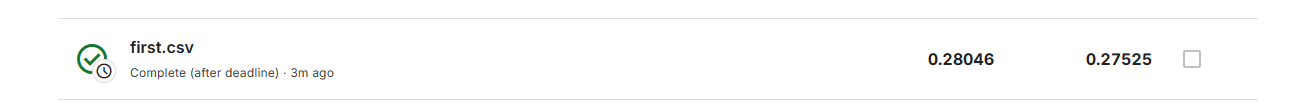

# Features engineering и обработка пропусков

## 1. Feature importance

### Поиск самых важных фич

### Обученме только на них

## 1. Фичи из бинарных признаков

### a) Удалить бинарные признаки

### б) Удалить все бинарные признаки, добавив суммы бинарных ps_ind и ps_calc

### в) Оставить исходные и добавить суммы бинарных ps_ind и ps_calc

## 2. Влияние ps_calc_ признаков

### а) Удалить ps_calc_

### б) Оставить ps_calc_

## 2. Фичи из категориальных признаков

### Мода + индикатор пропуска для значимых фич

Добавим индикатор пропусков только для тех фич, где они занимали значимое число от общей массы столбцов и была заметна зависимость с таргетом.

In [ ]:
missing_indicator_features = [
    "ps_ind_05_cat",
    "ps_car_07_cat",
]

### `-1` отдельная категория

## Фичи из числовых признаков

### Среднее арифметическое + индикатор пропусков